In [1]:
from collections.abc import Iterable, Generator, Sequence
from dataclasses import dataclass
from math import tau, cos, sin, ceil, floor, log10, pow
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator, FixedLocator
from itertools import batched
from functools import reduce, partial
from typing import TypeVar, Callable
import numpy as np

In [2]:
def samples_per_bit(sr: int, f: int, n: int) -> int:
    return (n * sr) // f


def to_nrz(bit: bool) -> int:
    return int(bit) * 2 - 1


def modulate_sample(a: float, cw: float, dw: float, t: float, dt: float) -> float:
    return a * cos(cw * t + dw * dt)


@dataclass
class Spec:
    sample_rate: int
    mark_frequency: int
    mark_num_periods: int
    mark_power_threshold_db: float
    space_frequency: int
    space_num_periods: int
    space_power_threshold_db: float
    low: int
    high: int

    @classmethod
    def with_kcs(cls) -> 'Spec':
        return Spec(9600, 2400, 8, 44, 1200, 4, -44, -127, 127)

    def bit_width(self) -> int:
        return samples_per_bit(self.sample_rate, self.mark_frequency, self.mark_num_periods)


def interpolate(steps, data: Sequence[int]) -> Generator[float, None, None]:
    n = steps * len(data)
    yield 0
    for i in range(1, n):
        index = int(ceil((i + 1) / steps)) - 1
        index_prev = int(ceil(i / steps)) - 1
        yield (data[index_prev] + data[index]) / 2


assert list(interpolate(2, list(range(0, 4)))) == [0, 0, 0.5, 1, 1.5, 2, 2.5, 3]


def integrate(data: Iterable[float]) -> Generator[float, None, None]:
    m = 0.0
    for d in data:
        m += d
        yield m


assert list(integrate([0, 3, 2])) == [0, 3, 5]


def modulate(spec: Spec, data: Iterable[bool]) -> Generator[int, None, None]:
    # Amplitude settings
    amplitude = (spec.high - spec.low) / 2

    # Frequency settings
    carrier_freq = (spec.mark_frequency + spec.space_frequency) // 2
    delta_freq = abs(spec.mark_frequency - spec.space_frequency) // 2
    sample_rate = spec.sample_rate
    carrier_omega = tau * (carrier_freq / sample_rate)
    delta_omega = tau * (delta_freq / sample_rate)

    window_size = spec.bit_width()

    nrz_data = (to_nrz(bit) for bit in data)
    interpolated_data = interpolate(window_size, list(nrz_data))
    integrated_data = integrate(interpolated_data)
    for i, m in enumerate(integrated_data):
        y = modulate_sample(amplitude, carrier_omega, delta_omega, float(i), m)
        yield int(y)


assert len(list(modulate(Spec.with_kcs(), [True, False]))) % Spec.with_kcs().bit_width() == 0


def center(signal: Sequence[float]) -> Generator[float, None, None]:
    dc_offset = sum(signal) / len(signal)
    return (sample - dc_offset for sample in signal)


def normalize(signal: Sequence[float]) -> Generator[float, None, None]:
    max_amplitude = max(abs(sample) for sample in signal)
    return (sample / max_amplitude for sample in signal)


def fill(signal: Iterable[float], target_length: int, value: float) -> Generator[float, None, None]:
    for i, sample in enumerate(signal):
        yield sample

    for j in range((i + 1), target_length):
        yield value


assert list(fill([1.0], 2, 0.0)) == [1.0, 0.0]
assert list(fill([1.0, 1.0], 2, 0.0)) == [1.0, 1.0]
assert list(fill([2.0, 3.0, 4.0], 2, 0.0)) == [2.0, 3.0, 4.0]


def to_decibel(p: float, p_0: float) -> float:
    return 10.0 * log10((p + 1e-10) / (p_0 + 1e-10))


@dataclass(frozen=True, slots=True)
class DftTerm:
    frequency: int
    omega_real: float
    omega_imag: float
    d1: float
    d2: float

    def power(self) -> float:
        return  pow(self.d2, 2) + pow(self.d1, 2) - self.omega_real * self.d1 * self.d2
    

@dataclass(frozen=True, slots=True)
class Output:
    mark: DftTerm
    space: DftTerm

    def rel_power(self) -> float:
        return to_decibel(self.mark.power(), self.space.power())


def k_term(sr: int, f: int, w: int) -> int:
    return int(round((w * f) / sr))


def filter_pass(state: (float, float), sample: float, omega_real: float) -> tuple[float, float]:
    (d1, d2) = state
    y = sample + omega_real * d1 - d2
    return (y, d1)


def goertzel(sample_rate: int, frequency: int, data: Sequence[float]) -> DftTerm:
    window_size = len(data)
    k = k_term(sample_rate, frequency, window_size)
    omega = tau * k / window_size
    omega_real = 2.0 * cos(omega)
    omega_imag = sin(omega)

    d1, d2 = reduce(partial(filter_pass, omega_real=omega_real), data, (0, 0))

    return DftTerm(
        frequency,
        omega_real,
        omega_imag,
        d1,
        d2,
    )


def goertzel_with_spec(spec: Spec, data: Sequence[float]) -> Output:
    return Output(
        mark=goertzel(spec.sample_rate, spec.mark_frequency, data),
        space=goertzel(spec.sample_rate, spec.space_frequency, data),
    )


def classify_dumb(spec: Spec, power_db: float) -> bool | None:
    if power_db > spec.mark_power_threshold_db:
        return True
    elif power_db < spec.space_power_threshold_db:
        return False
    else:
        return None


def classify_with_hysteresis(state: bool, power_db: float, spec: Spec) -> tuple[bool, bool]:
    if state and power_db < spec.space_power_threshold_db:
        return (state, False)
    elif not state and power_db > spec.mark_power_threshold_db:
        return (state, True)
    else:
        return (state, state)


T = TypeVar('T')
S = TypeVar('S')
U = TypeVar('U')
def scan(func: Callable[[S, T], tuple[S, U]], data: Iterable[T], initial: S) -> Generator[U, None, None]:
    state = initial
    for element in data:
        state, output = func(state, element)
        yield output


def demodulate(spec: Spec, data: Iterable[int]) -> Generator[bool, None, None]:
    window_size = spec.bit_width()

    data_float = (float(sample) for sample in data)
    data_centered = center(list(data_float))
    data_normalized = normalize(list(data_centered))
    data_windowed = batched(data_normalized, window_size)
    relative_powers = (goertzel_with_spec(spec, list(window)).rel_power() for window in data_windowed)
    #classified = (classify_dumb(spec, sample) for sample in relative_powers)
    classified = scan(partial(classify_with_hysteresis, spec=spec), relative_powers, False)
    return classified

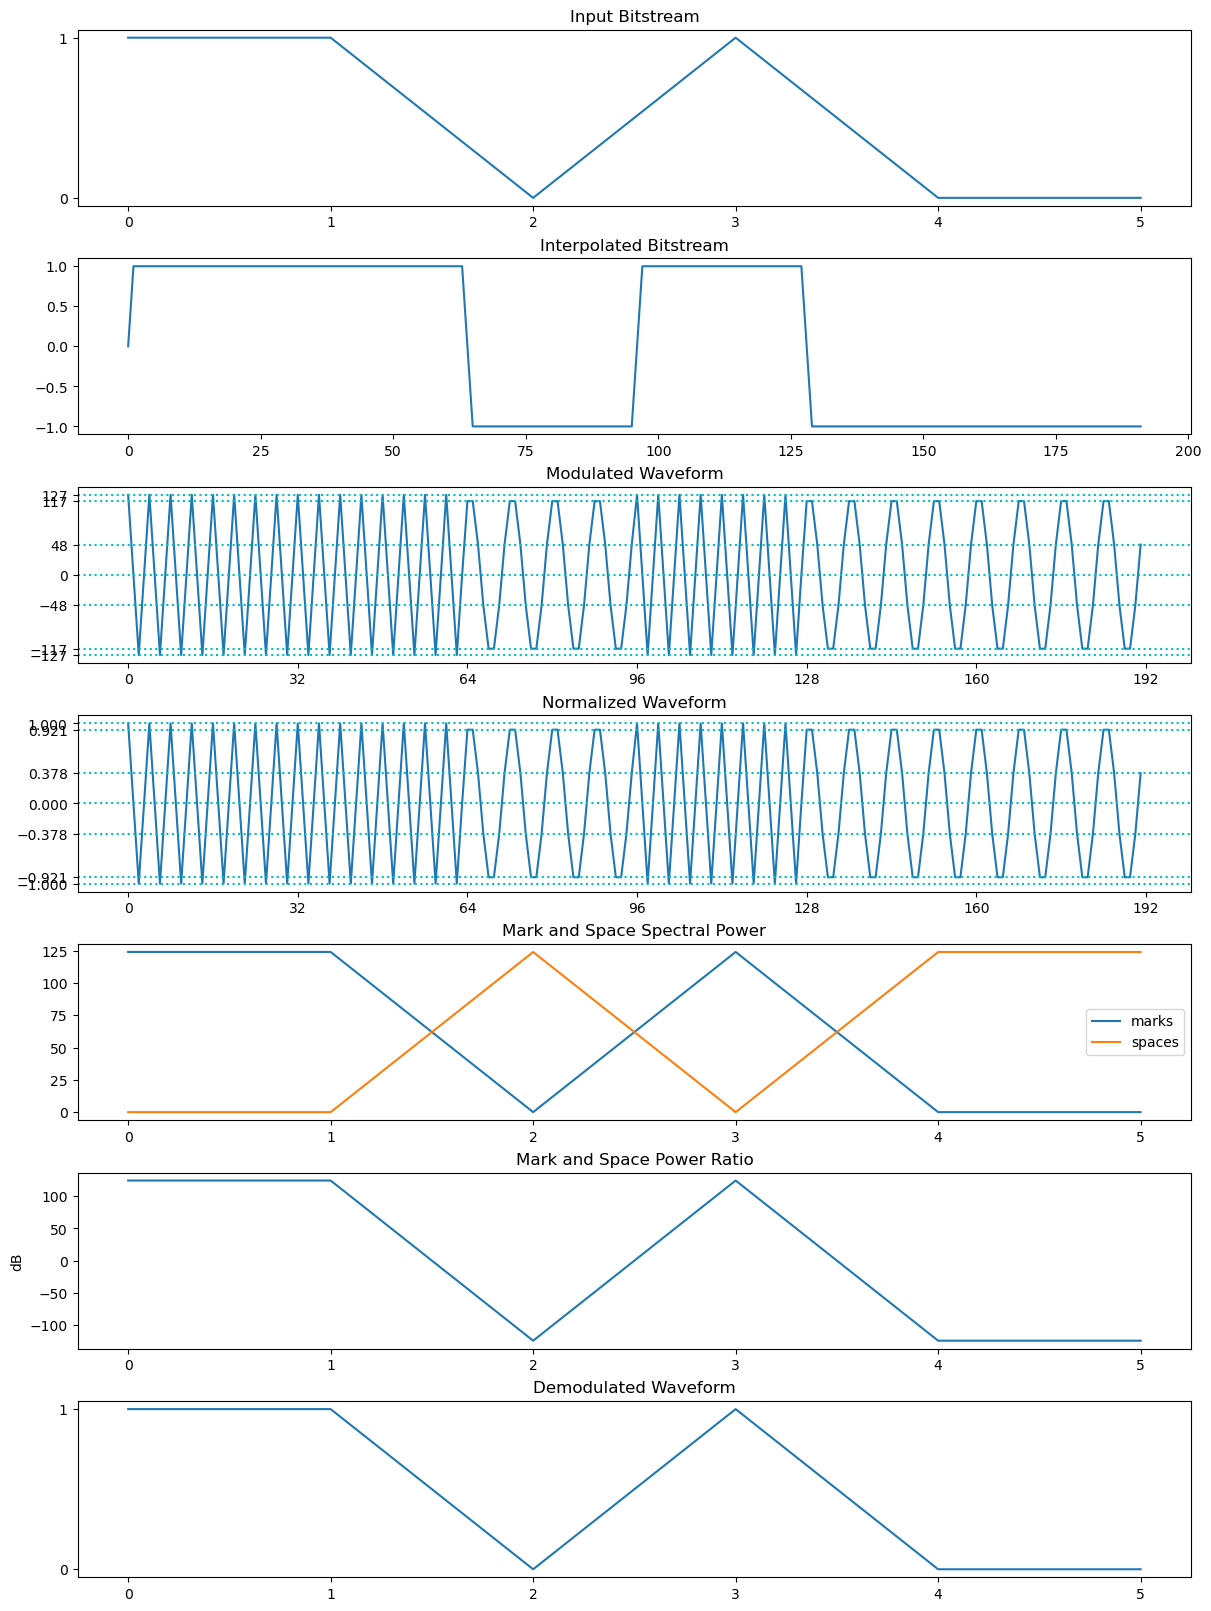

In [4]:
spec = Spec.with_kcs()
window_size = spec.bit_width()
bitstream_input = np.array([True, True, False, True, False, False])

# This is the exploded modulation function
nrz_data = (to_nrz(bit) for bit in bitstream_input)
bitstream_interpolated = list(interpolate(window_size, list(nrz_data)))
waveform = np.array(list(modulate(spec, bitstream_input)))

unique_y_values = np.unique(waveform)


# This is the exploded demodulation function
data_float = (float(sample) for sample in waveform)
data_centered = center(list(data_float))
data_normalized = np.array(list(normalize(list(data_centered))))
data_windowed = batched(data_normalized, window_size)
goertzel_output = [goertzel_with_spec(spec, list(window)) for window in data_windowed]
mark_powers = np.array([to_decibel(o.mark.power(), 0) for o in goertzel_output])
space_powers = np.array([to_decibel(o.space.power(), 0) for o in goertzel_output])
relative_powers = np.array([o.rel_power() for o in goertzel_output])

bitstream_output = np.array(list(demodulate(spec, waveform)))

fig = plt.figure(figsize=(12, 16), dpi=100, layout='constrained')
axs = fig.subplot_mosaic([
        ['input'],
        ['interpolated'],
        ['waveform'],
        ['normalized'],
        ['power'],
        ['rel_power'],
        ['output'],
    ])
axs['input'].plot(np.arange(0, len(bitstream_input)), bitstream_input)
axs['input'].set_title('Input Bitstream')
axs['input'].yaxis.set_major_locator(FixedLocator([0.0, 1.0]))
axs['interpolated'].plot(np.arange(0, len(bitstream_interpolated)), bitstream_interpolated)
axs['interpolated'].set_title('Interpolated Bitstream')
axs['waveform'].plot(np.arange(0, len(waveform)), waveform)
axs['waveform'].hlines(np.unique(waveform), 0, 1, transform=axs['waveform'].get_yaxis_transform(), colors='c', linestyles='dotted')
axs['waveform'].xaxis.set_major_locator(MultipleLocator(spec.bit_width()))
axs['waveform'].yaxis.set_major_locator(FixedLocator(np.unique(waveform)))
axs['waveform'].set_title('Modulated Waveform')
axs['normalized'].plot(np.arange(0, len(data_normalized)), data_normalized)
axs['normalized'].hlines(np.unique(data_normalized), 0, 1, transform=axs['normalized'].get_yaxis_transform(), colors='c', linestyles='dotted')
axs['normalized'].xaxis.set_major_locator(MultipleLocator(spec.bit_width()))
axs['normalized'].yaxis.set_major_locator(FixedLocator(np.unique(data_normalized)))
axs['normalized'].set_title('Normalized Waveform')
axs['power'].plot(np.arange(0, len(mark_powers)), mark_powers, label='marks')
axs['power'].plot(np.arange(0, len(space_powers)), space_powers, label='spaces')
axs['power'].legend()
axs['power'].set_title('Mark and Space Spectral Power')
axs['rel_power'].plot(np.arange(0, len(relative_powers)), relative_powers)
axs['rel_power'].yaxis.set_label_text('dB')
axs['rel_power'].set_title('Mark and Space Power Ratio')
axs['output'].plot(np.arange(0, len(bitstream_output)), bitstream_output)
axs['output'].yaxis.set_major_locator(FixedLocator([0.0, 1.0]))
axs['output'].set_title('Demodulated Waveform')

assert (bitstream_input == bitstream_output).all()